### Задание

Создайте систему компьютерного зрения, которая будет определять тип геометрической фигуры. Используя подготовленную базу и шаблон ноутбука проведите серию экспериментов по перебору гиперпараметров нейронной сети, распознающей три категории изображений (треугольник, круг, квадрат).

1. Поменяйте количество нейронов в сети, используя следующие значения:

- один слой 10 нейронов
- один слой 100 нейронов
- один слой 5000 нейронов.

2. Поменяйте активационную функцию в скрытых слоях с `relu` на `linear`.
3. Поменяйте размеры batch_size:
- 10
- 100
- 1000

4. Выведите на экран получившиеся точности.

Всего должно получиться 18 комбинаций указанных параметров.

Создайте сравнительную таблицу по результатам проведенных тестов.

## Подключение библиотек

In [3]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from PIL import Image
import random


## Загрузка датасета

In [4]:
# Загрузка датасета из облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_light.zip', None, quiet=True)

'hw_light.zip'

In [5]:
# Распаковываем архив hw_light.zip в папку hw_light
!unzip -q hw_light.zip

## Подготовка данных

In [6]:
base_dir = '/content/hw_light'

x_train = []
y_train = []

img_height = 20
img_width = 20

for patch in os.listdir(base_dir):
    patch_path = os.path.join(base_dir, patch)

    for file_name in os.listdir(patch_path):
        img_path = os.path.join(patch_path, file_name)

        img = Image.open(img_path).convert('L')  # grayscale

        img = img.resize((img_width, img_height))

        img_array = np.array(img)

        img_array = img_array.reshape(img_height, img_width, 1)

        x_train.append(img_array)

        if patch == '0':
            y_train.append(0)
        elif patch == '3':
            y_train.append(1)
        else:
            y_train.append(2)

# в numpy
x_train = np.array(x_train)
y_train = np.array(y_train)

print('Размер массива x_train', x_train.shape)
print('Размер массива y_train', y_train.shape)

Размер массива x_train (302, 20, 20, 1)
Размер массива y_train (302,)


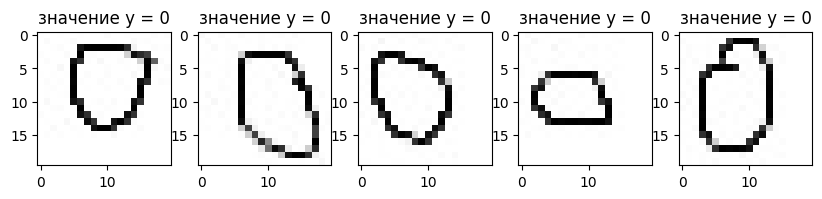

In [7]:
plt.figure(figsize=(10, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    img = x_train[i].reshape(20, 20)

    plt.imshow(img, cmap='gray')
    plt.title(f"значение y = {y_train[i]}")

plt.show()

## Подготовка данных перед созданием модели

In [8]:
x_train = x_train.reshape(x_train.shape[0], -1)
x_train.shape
x_train = x_train.astype('float32') / 255.

## Создание модели и компиляция

In [10]:
class ShapeClassifier(nn.Module):
    def __init__(self, hidden_units=10, activation='relu'):
        super().__init__()

        if activation == 'relu':
            act = nn.ReLU()
        elif activation == 'linear':
            act = nn.Identity()
        else:
            raise ValueError("activation must be 'relu' or 'linear'")

        self.net = nn.Sequential(
            nn.Linear(400, 400),
            nn.ReLU(),
            nn.Linear(400, hidden_units),
            act,
            nn.Linear(hidden_units, 3)
        )

    def forward(self, x):
        return self.net(x)

## Функция обучения

In [11]:
def run_experiment(
    x_train,
    y_train,
    hidden_units=10,
    activation='relu',
    batch_size=10,
    epochs=15,
    learning_rate=0.001,
    device=None
):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    x_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.long)

    dataset = TensorDataset(x_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = ShapeClassifier(hidden_units=hidden_units, activation=activation).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {'loss': [], 'accuracy': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_x.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)

        epoch_loss = total_loss / total
        epoch_acc = correct / total

        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)

    return model, history['accuracy'][-1], history

## Запуск 18 комбинаций обучения моделей

In [16]:
results = []

for hidden_units in [10, 100, 5000]:
    for activation in ['relu', 'linear']:
        for batch_size in [10, 100, 1000]:
            print(f"Количество нейронов={hidden_units}, Активация={activation}, batch_size={batch_size}")

            model, acc, history = run_experiment(
                x_train=x_train,
                y_train=y_train,
                hidden_units=hidden_units,
                activation=activation,
                batch_size=batch_size,
                epochs=15
            )

            val_acc = history['accuracy'][-1]

            print(f"accuracy: {val_acc:.4f}")

Количество нейронов=10, Активация=relu, batch_size=10
accuracy: 0.8709
Количество нейронов=10, Активация=relu, batch_size=100
accuracy: 0.6954
Количество нейронов=10, Активация=relu, batch_size=1000
accuracy: 0.7450
Количество нейронов=10, Активация=linear, batch_size=10
accuracy: 0.9702
Количество нейронов=10, Активация=linear, batch_size=100
accuracy: 0.7748
Количество нейронов=10, Активация=linear, batch_size=1000
accuracy: 0.8477
Количество нейронов=100, Активация=relu, batch_size=10
accuracy: 0.9735
Количество нейронов=100, Активация=relu, batch_size=100
accuracy: 0.7517
Количество нейронов=100, Активация=relu, batch_size=1000
accuracy: 0.8311
Количество нейронов=100, Активация=linear, batch_size=10
accuracy: 0.9901
Количество нейронов=100, Активация=linear, batch_size=100
accuracy: 0.8146
Количество нейронов=100, Активация=linear, batch_size=1000
accuracy: 0.7947
Количество нейронов=5000, Активация=relu, batch_size=10
accuracy: 0.9801
Количество нейронов=5000, Активация=relu, bat